
Analyzing learning rate: 0.1
Episode 100, Win Rate: 0.62
Episode 200, Win Rate: 0.55
Episode 300, Win Rate: 0.49
Episode 400, Win Rate: 0.56
Episode 500, Win Rate: 0.60
Episode 600, Win Rate: 0.49
Episode 700, Win Rate: 0.60
Episode 800, Win Rate: 0.36
Episode 900, Win Rate: 0.45
Episode 1000, Win Rate: 0.30
Episode 1100, Win Rate: 0.58
Episode 1200, Win Rate: 0.51
Episode 1300, Win Rate: 0.63
Episode 1400, Win Rate: 0.55
Episode 1500, Win Rate: 0.34
Episode 1600, Win Rate: 0.55
Episode 1700, Win Rate: 0.51
Episode 1800, Win Rate: 0.49
Episode 1900, Win Rate: 0.50
Episode 2000, Win Rate: 0.45
Episode 2100, Win Rate: 0.59
Episode 2200, Win Rate: 0.49
Episode 2300, Win Rate: 0.36
Episode 2400, Win Rate: 0.36
Episode 2500, Win Rate: 0.50
Episode 2600, Win Rate: 0.35
Episode 2700, Win Rate: 0.38
Episode 2800, Win Rate: 0.45
Episode 2900, Win Rate: 0.39
Episode 3000, Win Rate: 0.43
Episode 3100, Win Rate: 0.38
Episode 3200, Win Rate: 0.35
Episode 3300, Win Rate: 0.51
Episode 3400, Win Rate

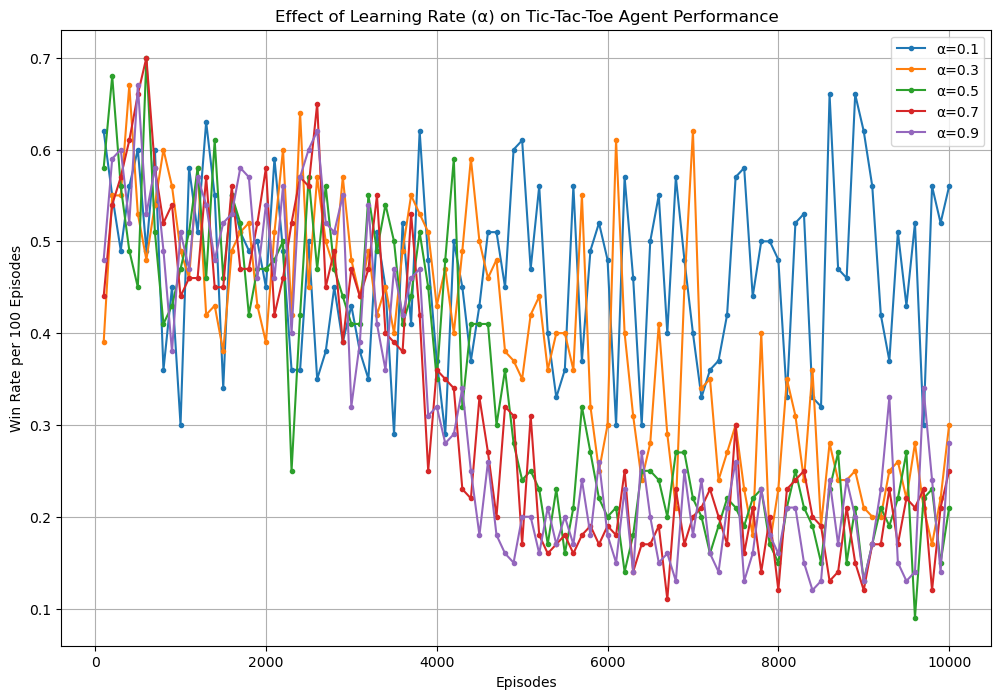

In [2]:
import random
from copy import copy, deepcopy
import csv
import matplotlib.pyplot as plt
import numpy as np

EMPTY = 0
PLAYER_X = 1
PLAYER_O = 2
DRAW = 3

BOARD_FORMAT = "----------------------------\n| {0} | {1} | {2} |\n|--------------------------|\n| {3} | {4} | {5} |\n|--------------------------|\n| {6} | {7} | {8} |\n----------------------------"
NAMES = [' ', 'X', 'O']
def printboard(state):
    cells = []
    for i in range(3):
        for j in range(3):
            cells.append(NAMES[state[i][j]].center(6))
    print(BOARD_FORMAT.format(*cells))

def emptystate():
    return [[EMPTY,EMPTY,EMPTY],[EMPTY,EMPTY,EMPTY],[EMPTY,EMPTY,EMPTY]]

def gameover(state):
    for i in range(3):
        if state[i][0] != EMPTY and state[i][0] == state[i][1] and state[i][0] == state[i][2]:
            return state[i][0]
        if state[0][i] != EMPTY and state[0][i] == state[1][i] and state[0][i] == state[2][i]:
            return state[0][i]
    if state[0][0] != EMPTY and state[0][0] == state[1][1] and state[0][0] == state[2][2]:
        return state[0][0]
    if state[0][2] != EMPTY and state[0][2] == state[1][1] and state[0][2] == state[2][0]:
        return state[0][2]
    for i in range(3):
        for j in range(3):
            if state[i][j] == EMPTY:
                return EMPTY
    return DRAW

def last_to_act(state):
    countx = 0
    counto = 0
    for i in range(3):
        for j in range(3):
            if state[i][j] == PLAYER_X:
                countx += 1
            elif state[i][j] == PLAYER_O:
                counto += 1
    if countx == counto:
        return PLAYER_O
    if countx == (counto + 1):
        return PLAYER_X
    return -1


def enumstates(state, idx, agent):
    if idx > 8:
        player = last_to_act(state)
        if player == agent.player:
            agent.add(state)
    else:
        winner = gameover(state)
        if winner != EMPTY:
            return
        i = int(idx / 3)
        j = int(idx % 3)
        for val in range(3):
            state[i][j] = val
            enumstates(state, idx+1, agent)

class Agent(object):
    def __init__(self, player, verbose=False, lossval=0, learning=True, alpha=0.99):
        self.values = {}
        self.player = player
        self.verbose = verbose
        self.lossval = lossval
        self.learning = learning
        self.epsilon = 0.1
        self.alpha = alpha  # Learning rate parameter
        self.prevstate = None
        self.prevscore = 0
        self.count = 0
        enumstates(emptystate(), 0, self)

    def episode_over(self, winner):
        self.backup(self.winnerval(winner))
        self.prevstate = None
        self.prevscore = 0

    def action(self, state):
        r = random.random()
        if r < self.epsilon:
            move = self.random(state)
            self.log('>>>>>>> Exploratory action: ' + str(move))
        else:
            move = self.greedy(state)
            self.log('>>>>>>> Best action: ' + str(move))
        state[move[0]][move[1]] = self.player
        self.prevstate = self.statetuple(state)
        self.prevscore = self.lookup(state)
        state[move[0]][move[1]] = EMPTY
        return move

    def random(self, state):
        available = []
        for i in range(3):
            for j in range(3):
                if state[i][j] == EMPTY:
                    available.append((i,j))
        return random.choice(available)

    def greedy(self, state):
        maxval = -50000
        maxmove = None
        if self.verbose:
            cells = []
        for i in range(3):
            for j in range(3):
                if state[i][j] == EMPTY:
                    state[i][j] = self.player
                    val = self.lookup(state)
                    state[i][j] = EMPTY
                    if val > maxval:
                        maxval = val
                        maxmove = (i, j)
                    if self.verbose:
                        cells.append('{0:.3f}'.format(val).center(6))
                elif self.verbose:
                    cells.append(NAMES[state[i][j]].center(6))
        if self.verbose:
            print(BOARD_FORMAT.format(*cells))
        self.backup(maxval)
        return maxmove

    def backup(self, nextval):
        if self.prevstate != None and self.learning:
            self.values[self.prevstate] += self.alpha * (nextval - self.prevscore)

    def lookup(self, state):
        key = self.statetuple(state)
        if not key in self.values:
            self.add(key)
        return self.values[key]

    def add(self, state):
        winner = gameover(state)
        tup = self.statetuple(state)
        self.values[tup] = self.winnerval(winner)

    def winnerval(self, winner):
        if winner == self.player:
            return 1
        elif winner == EMPTY:
            return 0.5
        elif winner == DRAW:
            return 0
        else:
            return self.lossval

    def statetuple(self, state):
        return (tuple(state[0]),tuple(state[1]),tuple(state[2]))

    def log(self, s):
        if self.verbose:
            print(s)

def play(agent1, agent2):
    state = emptystate()
    for i in range(9):
        if i % 2 == 0:
            move = agent1.action(state)
        else:
            move = agent2.action(state)
        state[move[0]][move[1]] = (i % 2) + 1
        winner = gameover(state)
        if winner != EMPTY:
            return winner
    return winner

class Human(object):
    def __init__(self, player):
        self.player = player

    def action(self, state):
        printboard(state)
        action = input('Your move? i.e. x,y : ')
        return (int(action.split(',')[0]),int(action.split(',')[1]))

    def episode_over(self, winner):
        if winner == DRAW:
            print('Game over! It was a draw.')
        else:
            print('Game over! Winner: Player {0}'.format(winner))

def play(agent1, agent2):
    state = emptystate()
    for i in range(9):
        if i % 2 == 0:
            move = agent1.action(state)
        else:
            move = agent2.action(state) 
        state[move[0]][move[1]] = (i % 2) + 1
        winner = gameover(state)
        if winner != EMPTY:
            return winner
    return winner

def measure_performance_vs_random(agent1, agent2):
    epsilon1 = agent1.epsilon
    epsilon2 = agent2.epsilon
    agent1.epsilon = 0
    agent2.epsilon = 0
    agent1.learning = False
    agent2.learning = False
    r1 = Agent(1)
    r2 = Agent(2)
    r1.epsilon = 1
    r2.epsilon = 1
    probs = [0,0,0,0,0,0]
    games = 100
    for i in range(games):
        winner = play(agent1, r2)
        if winner == PLAYER_X:
            probs[0] += 1.0 / games
        elif winner == PLAYER_O:
            probs[1] += 1.0 / games
        else:
            probs[2] += 1.0 / games
    for i in range(games):
        winner = play(r1, agent2)
        if winner == PLAYER_O:
            probs[3] += 1.0 / games
        elif winner == PLAYER_X:
            probs[4] += 1.0 / games
        else:
            probs[5] += 1.0 / games
    agent1.epsilon = epsilon1
    agent2.epsilon = epsilon2
    agent1.learning = True
    agent2.learning = True
    return probs

def measure_performance_vs_each_other(agent1, agent2):
    probs = [0,0,0]
    games = 100
    for i in range(games):
        winner = play(agent1, agent2)
        if winner == PLAYER_X:
            probs[0] += 1.0 / games
        elif winner == PLAYER_O:
            probs[1] += 1.0 / games
        else:
            probs[2] += 1.0 / games
    return probs

def analyze_learning_rates(episodes=10000, eval_interval=100):
    learning_rates = [0.1, 0.3, 0.5, 0.7, 0.9]
    results = {alpha: [] for alpha in learning_rates}
    
    for alpha in learning_rates:
        print(f"\nAnalyzing learning rate: {alpha}")
        
        # Initialize agents with current learning rate
        p1 = Agent(1, lossval=-1, alpha=alpha)
        p2 = Agent(2, lossval=-1, alpha=alpha)
        
        # Track wins over episodes
        wins = 0
        episode_wins = []
        
        for episode in range(1, episodes + 1):
            winner = play(p1, p2)
            p1.episode_over(winner)
            p2.episode_over(winner)
            
            if winner == PLAYER_X:
                wins += 1
                
            # Calculate win rate every eval_interval episodes
            if episode % eval_interval == 0:
                win_rate = wins / eval_interval
                episode_wins.append(win_rate)
                wins = 0  # Reset counter
                print(f"Episode {episode}, Win Rate: {win_rate:.2f}")
                
        results[alpha] = episode_wins
    
    # Plotting
    plt.figure(figsize=(12, 8))
    episode_numbers = np.arange(eval_interval, episodes + 1, eval_interval)
    
    for alpha, win_rates in results.items():
        plt.plot(episode_numbers, win_rates, label=f'α={alpha}', marker='o', markersize=3)
    
    plt.xlabel('Episodes')
    plt.ylabel('Win Rate per 100 Episodes')
    plt.title('Effect of Learning Rate (α) on Tic-Tac-Toe Agent Performance')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    analyze_learning_rates()